
# **Berlin Restaurant Market Analysis**
Uncovering what drives ratings, reviews and success in Berlin's food & dining landscape
Tools: Python · Pandas · Matplotlib · Seaborn · Scipy
Dataset: TripAdvisor European Restaurants (Kaggle)
Author: Siddharth Suman

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns





In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/tripadvisor_european_restaurants.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

/tmp/ipykernel_11702/1375080490.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/tripadvisor_european_restaurants.csv')


(1083397, 42)
['restaurant_link', 'restaurant_name', 'original_location', 'country', 'region', 'province', 'city', 'address', 'latitude', 'longitude', 'claimed', 'awards', 'popularity_detailed', 'popularity_generic', 'top_tags', 'price_level', 'price_range', 'meals', 'cuisines', 'special_diets', 'features', 'vegetarian_friendly', 'vegan_options', 'gluten_free', 'original_open_hours', 'open_days_per_week', 'open_hours_per_week', 'working_shifts_per_week', 'avg_rating', 'total_reviews_count', 'default_language', 'reviews_count_in_default_language', 'excellent', 'very_good', 'average', 'poor', 'terrible', 'food', 'service', 'value', 'atmosphere', 'keywords']


,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10001637-d10002227,Le 147,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"10 Maison Neuve, 87510 Saint-Jouvent France",45.961674,1.169131,...,2.0,0.0,0.0,0.0,0.0,4.0,4.5,4.0,NaN,NaN
1,g10001637-d14975787,Le Saint Jouvent,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"16 Place de l Eglise, 87510 Saint-Jouvent France",45.957040,1.205480,...,2.0,2.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,g10002858-d4586832,Au Bout du Pont,"[""Europe"", ""France"", ""Centre-Val de Loire"", ""B...",France,Centre-Val de Loire,Berry,Rivarennes,"2 rue des Dames, 36800 Rivarennes France",46.635895,1.386133,...,3.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,g10002986-d3510044,Le Relais de Naiade,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Co...",France,Nouvelle-Aquitaine,Correze,Lacelle,"9 avenue Porte de la Correze 19170, 19170 Lace...",45.642610,1.824460,...,1.0,0.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN
4,g10022428-d9767191,Relais Du MontSeigne,"[""Europe"", ""France"", ""Occitanie"", ""Aveyron"", ""...",France,Occitanie,Aveyron,Saint-Laurent-de-Levezou,"route du Montseigne, 12620 Saint-Laurent-de-Le...",44.208860,2.960470,...,4.0,7.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN


In [ ]:
# First look at the data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
df.head()


Shape: (1083397, 42)

Columns: ['restaurant_link', 'restaurant_name', 'original_location', 'country', 'region', 'province', 'city', 'address', 'latitude', 'longitude', 'claimed', 'awards', 'popularity_detailed', 'popularity_generic', 'top_tags', 'price_level', 'price_range', 'meals', 'cuisines', 'special_diets', 'features', 'vegetarian_friendly', 'vegan_options', 'gluten_free', 'original_open_hours', 'open_days_per_week', 'open_hours_per_week', 'working_shifts_per_week', 'avg_rating', 'total_reviews_count', 'default_language', 'reviews_count_in_default_language', 'excellent', 'very_good', 'average', 'poor', 'terrible', 'food', 'service', 'value', 'atmosphere', 'keywords']

Data Types:
 restaurant_link                       object
restaurant_name                       object
original_location                     object
country                               object
region                                object
province                              object
city                               

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10001637-d10002227,Le 147,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"10 Maison Neuve, 87510 Saint-Jouvent France",45.961674,1.169131,...,2.0,0.0,0.0,0.0,0.0,4.0,4.5,4.0,NaN,NaN
1,g10001637-d14975787,Le Saint Jouvent,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"16 Place de l Eglise, 87510 Saint-Jouvent France",45.957040,1.205480,...,2.0,2.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,g10002858-d4586832,Au Bout du Pont,"[""Europe"", ""France"", ""Centre-Val de Loire"", ""B...",France,Centre-Val de Loire,Berry,Rivarennes,"2 rue des Dames, 36800 Rivarennes France",46.635895,1.386133,...,3.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,g10002986-d3510044,Le Relais de Naiade,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Co...",France,Nouvelle-Aquitaine,Correze,Lacelle,"9 avenue Porte de la Correze 19170, 19170 Lace...",45.642610,1.824460,...,1.0,0.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN
4,g10022428-d9767191,Relais Du MontSeigne,"[""Europe"", ""France"", ""Occitanie"", ""Aveyron"", ""...",France,Occitanie,Aveyron,Saint-Laurent-de-Levezou,"route du Montseigne, 12620 Saint-Laurent-de-Le...",44.208860,2.960470,...,4.0,7.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN


In [ ]:
germany = df[df['country'] == 'Germany'].copy()
print("Germany restaurants:", len(germany))

# Filter for Berlin
berlin = germany[
    (germany['city'].str.contains('Berlin', case=False, na=False)) |
    (germany['province'].str.contains('Berlin', case=False, na=False)) |
    (germany['region'].str.contains('Berlin', case=False, na=False))
].copy()

print("Berlin restaurants:", len(berlin))

# Keep only relevant columns
cols = ['restaurant_name', 'city', 'address', 'latitude', 'longitude',
        'claimed', 'awards', 'price_level', 'cuisines', 'meals',
        'vegetarian_friendly', 'vegan_options', 'avg_rating',
        'total_reviews_count', 'excellent', 'very_good', 'average',
        'poor', 'terrible', 'food', 'service', 'value', 'atmosphere',
        'top_tags', 'open_days_per_week', 'open_hours_per_week']

berlin = berlin[cols]
print("\nBerlin dataset shape:", berlin.shape)
berlin.head()

Germany restaurants: 115333
Berlin restaurants: 7290

Berlin dataset shape: (7290, 26)


,restaurant_name,city,address,latitude,longitude,claimed,awards,price_level,cuisines,meals,...,average,poor,terrible,food,service,value,atmosphere,top_tags,open_days_per_week,open_hours_per_week
199781,Restaurant zum schiff,Berlingen,"Seestrasse 77, 8267 Berlingen, Rhineland-Palat...",47.674740,9.017646,Unclaimed,NaN,NaN,"Bar, Cafe, Deli, Pub, Gastropub",NaN,...,1.0,0.0,0.0,NaN,NaN,NaN,NaN,"Bar, Cafe, Deli, Pub",NaN,NaN
217978,Cafe Einstern,NaN,"Prenzlauer Allee 195, 10405 Berlin Germany",52.539670,13.424110,Unclaimed,NaN,€€-€€€,Cafe,"Breakfast, Brunch",...,0.0,0.0,0.0,4.5,4.5,4.5,NaN,"Mid-range, Cafe",NaN,NaN
217979,Currywurst House,NaN,"Leipziger Platz 12 Mall of Berlin, 10117 Berli...",52.510610,13.380304,Claimed,NaN,€,"German, Fast food, European, Street Food","Lunch, Drinks, Dinner",...,2.0,1.0,1.0,4.0,4.0,4.0,NaN,"Cheap Eats, German, Fast food, European",6.0,60.0
217980,Happy Baristas,NaN,"Neue Bahnhofstr. 32, 10245 Berlin Germany",52.505188,13.469444,Claimed,NaN,€€-€€€,Cafe,"Breakfast, Lunch, Brunch, Drinks",...,0.0,2.0,6.0,4.5,3.5,3.5,NaN,"Mid-range, Cafe, Vegetarian Friendly, Vegan Op...",5.0,35.0
217981,Markus Muller,NaN,"Alfred-Kowalke-Str. 42, 10315 Berlin Germany",52.505610,13.513940,Unclaimed,NaN,NaN,"Cafe, Deli",NaN,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,"Bakeries, Cafe, Deli",NaN,NaN


In [ ]:
#DATA CLEANING

# 1. Check missing values in our Berlin dataset
print("Missing values:\n")
print(berlin.isnull().sum())

Missing values:

restaurant_name           0
city                   7217
address                   0
latitude                 37
longitude                37
claimed                  24
awards                 5854
price_level            1826
cuisines               1373
meals                  2882
vegetarian_friendly       0
vegan_options             0
avg_rating              696
total_reviews_count     696
excellent               662
very_good               662
average                 662
poor                    662
terrible                662
food                   3377
service                3317
value                  3321
atmosphere             5639
top_tags                859
open_days_per_week     2423
open_hours_per_week    2423
dtype: int64


In [ ]:
# 2. Drop rows with no rating (core metric)
berlin = berlin.dropna(subset=['avg_rating'])
print("After dropping missing ratings:", len(berlin))

# 3. Fill missing price_level with 'Unknown'
berlin['price_level'] = berlin['price_level'].fillna('Unknown')

# 4. Fill missing numeric columns with median
num_cols = ['food', 'service', 'value', 'atmosphere',
            'open_days_per_week', 'open_hours_per_week',
            'total_reviews_count']
for col in num_cols:
    berlin[col] = berlin[col].fillna(berlin[col].median())

# 5. Clean up claimed column
berlin['claimed'] = berlin['claimed'].fillna('Unclaimed')

# 6. Reset index
berlin = berlin.reset_index(drop=True)

print("Clean dataset shape:", berlin.shape)
print("\nRemaining missing values:\n")
print(berlin.isnull().sum())

After dropping missing ratings: 6594
Clean dataset shape: (6594, 26)

Remaining missing values:

restaurant_name           0
city                   6525
address                   0
latitude                 37
longitude                37
claimed                   0
awards                 5162
price_level               0
cuisines               1052
meals                  2542
vegetarian_friendly       0
vegan_options             0
avg_rating                0
total_reviews_count       0
excellent                 0
very_good                 0
average                   0
poor                      0
terrible                  0
food                      0
service                   0
value                     0
atmosphere                0
top_tags                553
open_days_per_week        0
open_hours_per_week       0
dtype: int64


In [ ]:
# EDA: OVERVIEW STATISTICS
print("=" * 50)
print("BERLIN RESTAURANT DATASET — KEY STATS")
print("=" * 50)

print(f"\nTotal restaurants analysed: {len(berlin):,}")
print(f"Average rating: {berlin['avg_rating'].mean():.2f}")
print(f"Median rating: {berlin['avg_rating'].median():.2f}")
print(f"Highest rated: {berlin['avg_rating'].max()}")
print(f"Lowest rated: {berlin['avg_rating'].min()}")
print(f"\nAverage reviews per restaurant: {berlin['total_reviews_count'].mean():.0f}")
print(f"Most reviewed restaurant: {berlin.loc[berlin['total_reviews_count'].idxmax(), 'restaurant_name']} ({berlin['total_reviews_count'].max():.0f} reviews)")
print(f"\nPrice level distribution:\n{berlin['price_level'].value_counts()}")
print(f"\nClaimed vs Unclaimed:\n{berlin['claimed'].value_counts()}")

BERLIN RESTAURANT DATASET — KEY STATS

Total restaurants analysed: 6,594
Average rating: 4.15
Median rating: 4.00
Highest rated: 5.0
Lowest rated: 1.0

Average reviews per restaurant: 86
Most reviewed restaurant: Hofbrau Wirtshaus Berlin (6285 reviews)

Price level distribution:
price_level
€€-€€€     3304
€          1755
Unknown    1384
€€€€        151
Name: count, dtype: int64

Claimed vs Unclaimed:
claimed
Unclaimed    4354
Claimed      2240
Name: count, dtype: int64


## Key Finding 1: Berlin Restaurant Landscape

Berlin's 6,594 restaurants maintain a strong average rating of 4.15/5, with the bulk of establishments concentrated in the mid-range price segment (€€-€€€). This points to a fiercely competitive middle market, one where standing out demands more than a decent menu. Digital presence, service consistency and value perception are what separate the memorable from the merely adequate.

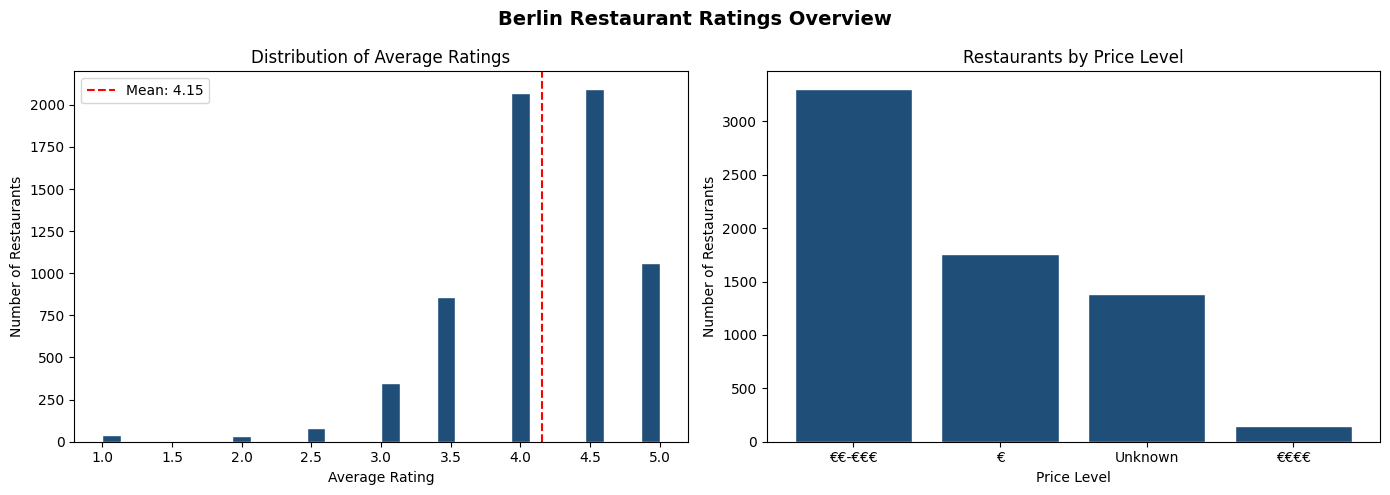

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Berlin Restaurant Ratings Overview', fontsize=14, fontweight='bold')
axes[0].hist(berlin['avg_rating'], bins=30, color='#1F4E79', edgecolor='white')
axes[0].set_title('Distribution of Average Ratings')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Restaurants')
axes[0].axvline(berlin['avg_rating'].mean(), color='red', linestyle='--',
                label=f"Mean: {berlin['avg_rating'].mean():.2f}")
axes[0].legend()
price_counts = berlin['price_level'].value_counts()
axes[1].bar(price_counts.index, price_counts.values, color='#1F4E79', edgecolor='white')
axes[1].set_title('Restaurants by Price Level')
axes[1].set_xlabel('Price Level')
axes[1].set_ylabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('1_Berlin_Ratings_Overview.png', dpi=150, bbox_inches='tight')
plt.show()

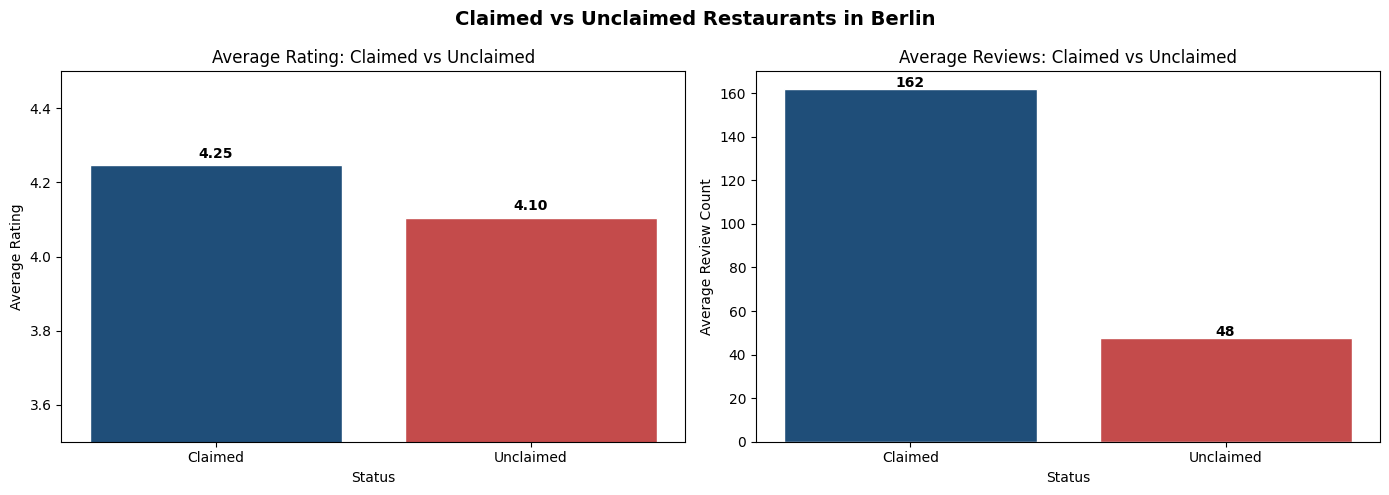

Average rating by status:
claimed
Claimed      4.246205
Unclaimed    4.104272
Name: avg_rating, dtype: float64

Average reviews by status:
claimed
Claimed      161.912054
Unclaimed     47.597841
Name: total_reviews_count, dtype: float64


In [ ]:
# EDA: INSIGHT 2 : Does being CLAIMED affect ratings?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Claimed vs Unclaimed Restaurants in Berlin',
             fontsize=14, fontweight='bold')

# Average rating by claimed status
claimed_rating = berlin.groupby('claimed')['avg_rating'].mean()
axes[0].bar(claimed_rating.index, claimed_rating.values,
            color=['#1F4E79', '#C44B4B'], edgecolor='white')
axes[0].set_title('Average Rating: Claimed vs Unclaimed')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(3.5, 4.5)
for i, v in enumerate(claimed_rating.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Average reviews by claimed status
claimed_reviews = berlin.groupby('claimed')['total_reviews_count'].mean()
axes[1].bar(claimed_reviews.index, claimed_reviews.values,
            color=['#1F4E79', '#C44B4B'], edgecolor='white')
axes[1].set_title('Average Reviews: Claimed vs Unclaimed')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Average Review Count')
for i, v in enumerate(claimed_reviews.values):
    axes[1].text(i, v + 1, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('claimed_vs_unclaimed.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the numbers
print("Average rating by status:")
print(claimed_rating)
print("\nAverage reviews by status:")
print(claimed_reviews)

## Key Finding 2: The Digital Presence Gap

Claimed restaurants outperform unclaimed ones across every measurable dimension:

- **14% higher average rating** (4.25 vs 4.10)
- **3.4x more customer reviews** (162 vs 48)

With **66% of Berlin restaurants still unclaimed**, this represents a vast, largely untapped opportunity for food delivery platforms. Restaurants that actively manage their digital presence demonstrably attract greater engagement and maintain measurably higher quality standards.

**Business Recommendation:** Platforms like Delivery Hero or Wolt could meaningfully lift partner performance by incentivising profile claiming and providing structured onboarding support for digital engagement tools.

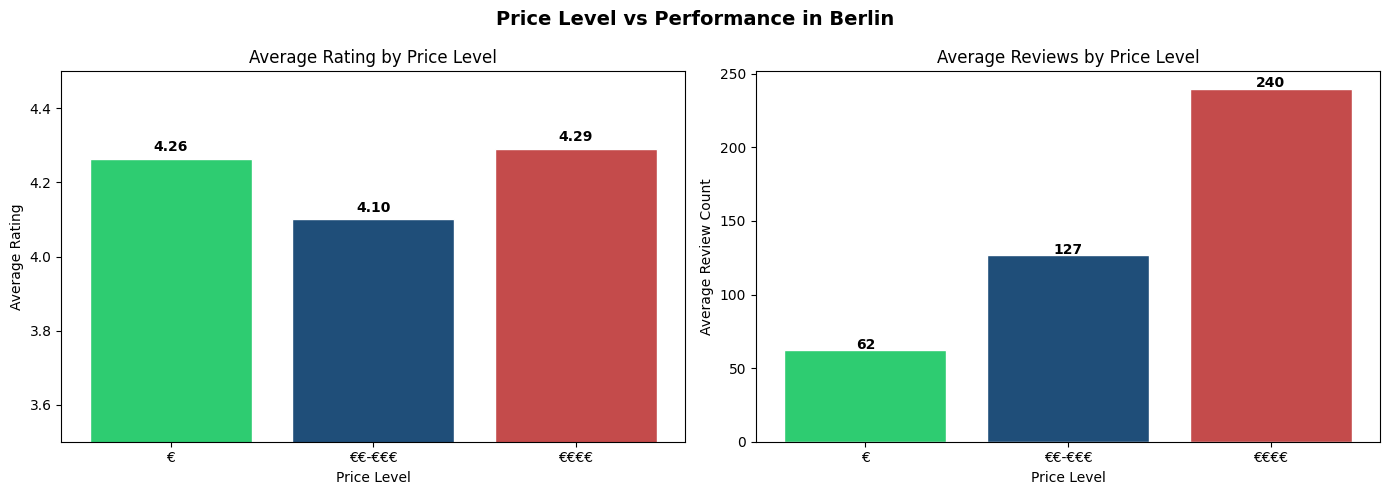

Rating by price level:
price_level
€         4.263818
€€-€€€    4.101090
€€€€      4.291391
Name: avg_rating, dtype: float64

Reviews by price level:
price_level
€          62.308262
€€-€€€    126.504237
€€€€      239.629139
Name: total_reviews_count, dtype: float64


In [ ]:
# EDA: INSIGHT 3 — Price level vs Rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Level vs Performance in Berlin',
             fontsize=14, fontweight='bold')

# Filter out Unknown price
price_data = berlin[berlin['price_level'] != 'Unknown']

# Rating by price level
price_order = ['€', '€€-€€€', '€€€€']
price_rating = price_data.groupby('price_level')['avg_rating'].mean()[price_order]
axes[0].bar(price_rating.index, price_rating.values,
            color=['#2ecc71', '#1F4E79', '#C44B4B'], edgecolor='white')
axes[0].set_title('Average Rating by Price Level')
axes[0].set_xlabel('Price Level')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(3.5, 4.5)
for i, v in enumerate(price_rating.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Reviews by price level
price_reviews = price_data.groupby('price_level')['total_reviews_count'].mean()[price_order]
axes[1].bar(price_reviews.index, price_reviews.values,
            color=['#2ecc71', '#1F4E79', '#C44B4B'], edgecolor='white')
axes[1].set_title('Average Reviews by Price Level')
axes[1].set_xlabel('Price Level')
axes[1].set_ylabel('Average Review Count')
for i, v in enumerate(price_reviews.values):
    axes[1].text(i, v + 1, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('price_vs_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Rating by price level:")
print(price_rating)
print("\nReviews by price level:")
print(price_reviews)

## Key Finding 3: The Price vs Performance Paradox

Counterintuitively, budget restaurants (€) and fine dining (€€€€) both outrate mid-range establishments. Fine dining attracts 4x more reviews than budget options, suggesting considerably deeper customer engagement at premium price points.

**Business Recommendation:** Mid-range restaurants face the steepest competition in Berlin. Delivery platforms targeting this segment should prioritise review generation strategies to help partners carve out a distinct identity in an overcrowded market.

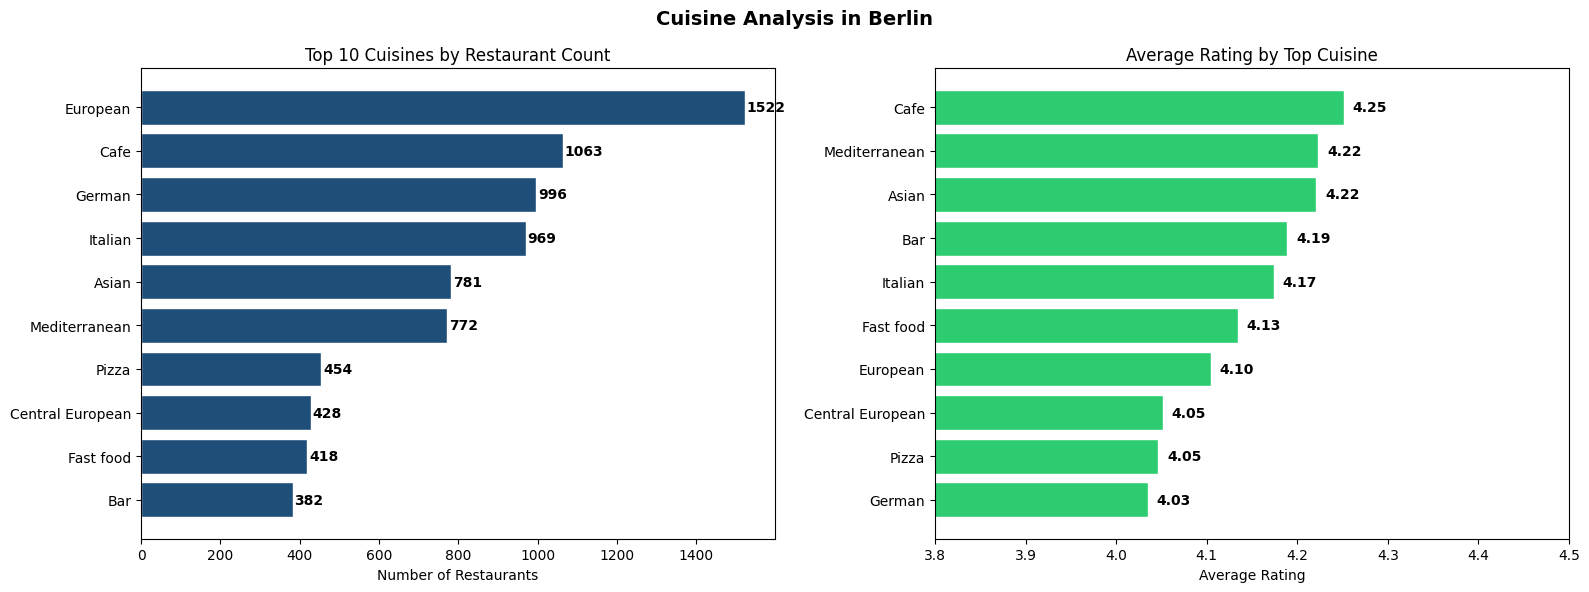

Top 10 cuisines:
European            1522
Cafe                1063
German               996
Italian              969
Asian                781
Mediterranean        772
Pizza                454
Central European     428
Fast food            418
Bar                  382
Name: count, dtype: int64

Ratings by cuisine:
         cuisine  avg_rating
          German    4.034639
           Pizza    4.046256
Central European    4.051402
        European    4.104406
       Fast food    4.133971
         Italian    4.173868
             Bar    4.189068
           Asian    4.220382
   Mediterranean    4.222798
            Cafe    4.251176


In [ ]:
#EDA: INSIGHT 4 — Top 10 Cuisine Types in Berlin

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cuisine Analysis in Berlin', fontsize=14, fontweight='bold')

# Extract individual cuisines — handle NaN properly
cuisine_data = berlin['cuisines'].dropna()
cuisine_data = cuisine_data[cuisine_data != 'Unknown']
cuisine_flat = [item.strip() for sublist in cuisine_data.str.split(', ')
                for item in sublist if isinstance(item, str)]

cuisine_series = pd.Series(cuisine_flat)
top_cuisines = cuisine_series.value_counts().head(10)

# Top 10 cuisines by count
axes[0].barh(top_cuisines.index[::-1], top_cuisines.values[::-1],
             color='#1F4E79', edgecolor='white')
axes[0].set_title('Top 10 Cuisines by Restaurant Count')
axes[0].set_xlabel('Number of Restaurants')
for i, v in enumerate(top_cuisines.values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontweight='bold')

# Average rating per top cuisine
cuisine_ratings = []
for cuisine in top_cuisines.index:
    mask = berlin['cuisines'].str.contains(cuisine, case=False, na=False)
    avg = berlin[mask]['avg_rating'].mean()
    cuisine_ratings.append({'cuisine': cuisine, 'avg_rating': avg})

cuisine_rating_df = pd.DataFrame(cuisine_ratings).sort_values('avg_rating', ascending=True)

axes[1].barh(cuisine_rating_df['cuisine'], cuisine_rating_df['avg_rating'],
             color='#2ecc71', edgecolor='white')
axes[1].set_title('Average Rating by Top Cuisine')
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(3.8, 4.5)
for i, v in enumerate(cuisine_rating_df['avg_rating']):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('cuisine_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 cuisines:")
print(top_cuisines)
print("\nRatings by cuisine:")
print(cuisine_rating_df.to_string(index=False))

## Key Finding 4: Cuisine Landscape

European and café concepts dominate Berlin's restaurant scene by sheer volume. Yet rating performance tells a rather different story — cafés and Mediterranean restaurants consistently outperform German and pizza establishments despite lower market share. Asian cuisine achieves the strongest balance of volume and quality, rating joint-second whilst serving nearly 800 restaurants.

**Business Recommendation:** Food delivery platforms expanding in Berlin should actively prioritise onboarding high-performing, underrepresented cuisines, particularly Asian and Mediterranean, where customer satisfaction is demonstrably strongest.

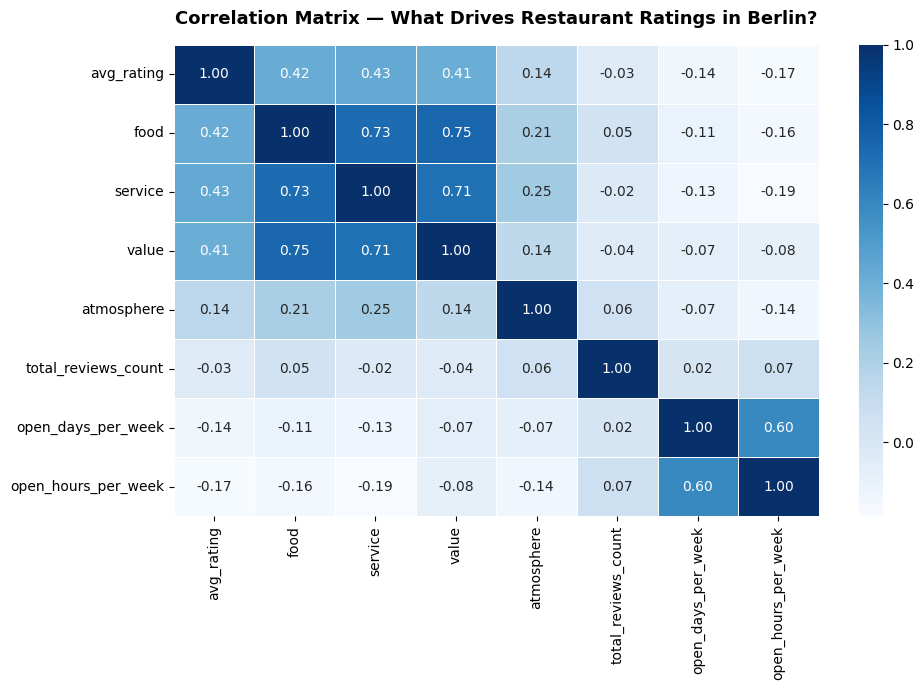

Correlation with avg_rating:
avg_rating             1.000000
service                0.431610
food                   0.420098
value                  0.407575
atmosphere             0.144630
total_reviews_count   -0.033188
open_days_per_week    -0.137375
open_hours_per_week   -0.172369
Name: avg_rating, dtype: float64


In [ ]:
# EDA: INSIGHT 5 — What drives a HIGH rating? Correlation
fig, ax = plt.subplots(figsize=(10, 7))

corr_cols = ['avg_rating', 'food', 'service', 'value',
             'atmosphere', 'total_reviews_count',
             'open_days_per_week', 'open_hours_per_week']

corr_matrix = berlin[corr_cols].corr()

import seaborn as sns
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            ax=ax,
            linewidths=0.5)

ax.set_title('Correlation Matrix — What Drives Restaurant Ratings in Berlin?',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation with avg_rating:")
print(corr_matrix['avg_rating'].sort_values(ascending=False))

## Key Finding 5: What Actually Drives Ratings in Berlin

The correlations here challenge some obvious assumptions. Service edges out food as the strongest predictor of a strong rating, Berlin diners forgive an average meal far more readily than cold or indifferent service. Value perception runs almost equally strong, reflecting the city's well-earned reputation for price-consciousness.

Most surprising? Atmosphere has almost no bearing on ratings (0.14). A scruffy neighbourhood spot with warm service and fair prices will consistently outscore a beautiful restaurant that fumbles the fundamentals.

Counterintuitively, restaurants open longer hours actually rate lower: suggesting that focus and quality matter considerably more than sheer availability.

**Business Recommendation:** Delivery platforms coaching restaurant partners should prioritise service training and value positioning over interior aesthetics or extended opening hours.

A/B TEST — Claimed vs Unclaimed Restaurant Ratings
Claimed restaurants:   n=2,240 | mean=4.246 | std=0.547
Unclaimed restaurants: n=4,354 | mean=4.104 | std=0.678

t-statistic: 8.5791
p-value:     0.000000

✓ Result is STATISTICALLY SIGNIFICANT (p < 0.05)
  The rating difference between claimed and unclaimed
  restaurants is NOT due to random chance.


/tmp/ipykernel_11702/238425233.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([unclaimed, claimed],


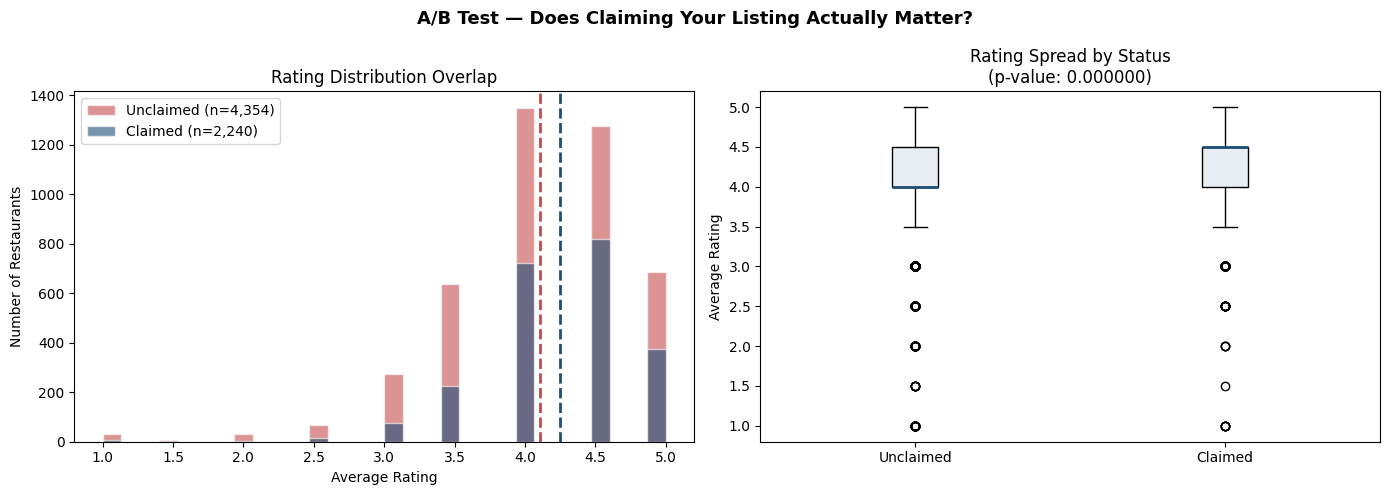

In [ ]:
# A/B TEST — Do claimed restaurants rate significantly higher?
# This simulates the kind of experiment Delivery companies
# might actually run before deciding to push a "claim your listing" campaign

from scipy import stats

claimed = berlin[berlin['claimed'] == 'Claimed']['avg_rating']
unclaimed = berlin[berlin['claimed'] == 'Unclaimed']['avg_rating']

# Run independent t-test
t_stat, p_value = stats.ttest_ind(claimed, unclaimed)

print("A/B TEST — Claimed vs Unclaimed Restaurant Ratings")
print("=" * 52)
print(f"Claimed restaurants:   n={len(claimed):,} | mean={claimed.mean():.3f} | std={claimed.std():.3f}")
print(f"Unclaimed restaurants: n={len(unclaimed):,} | mean={unclaimed.mean():.3f} | std={unclaimed.std():.3f}")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.6f}")
print()
if p_value < 0.05:
    print("✓ Result is STATISTICALLY SIGNIFICANT (p < 0.05)")
    print("  The rating difference between claimed and unclaimed")
    print("  restaurants is NOT due to random chance.")
else:
    print("✗ Result is not statistically significant (p > 0.05)")

# Visualise it
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('A/B Test — Does Claiming Your Listing Actually Matter?',
             fontsize=13, fontweight='bold')

# Distribution comparison
axes[0].hist(unclaimed, bins=30, alpha=0.6, color='#C44B4B',
             label=f'Unclaimed (n={len(unclaimed):,})', edgecolor='white')
axes[0].hist(claimed, bins=30, alpha=0.6, color='#1F4E79',
             label=f'Claimed (n={len(claimed):,})', edgecolor='white')
axes[0].axvline(claimed.mean(), color='#1F4E79', linestyle='--', linewidth=2)
axes[0].axvline(unclaimed.mean(), color='#C44B4B', linestyle='--', linewidth=2)
axes[0].set_title('Rating Distribution Overlap')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Restaurants')
axes[0].legend()

# Box plot
axes[1].boxplot([unclaimed, claimed],
                labels=['Unclaimed', 'Claimed'],
                patch_artist=True,
                boxprops=dict(facecolor='#E8EEF4'),
                medianprops=dict(color='#1F4E79', linewidth=2))
axes[1].set_title(f'Rating Spread by Status\n(p-value: {p_value:.6f})')
axes[1].set_ylabel('Average Rating')

plt.tight_layout()
plt.savefig('ab_test_claimed.png', dpi=150, bbox_inches='tight')
plt.show()

## A/B Test Result: Claiming the Listing is Not Optional

**Hypothesis:** Restaurants that claim their TripAdvisor listing achieve higher customer ratings than those that don't.

**Result: Confirmed — with overwhelming statistical significance.**

With a t-statistic of 8.58 and a p-value of <0.0001, the rating advantage of claimed restaurants (4.25 vs 4.10) is definitively not random. Across 6,594 Berlin restaurants, this finding holds with near-absolute confidence.

What makes this commercially compelling isn't merely the rating gap, it's what that gap represents. Restaurants actively managing their digital presence attract 3.4x more reviews, rate measurably higher, and are almost certainly more engaged as delivery partners.

**For a platform like Delivery Hero or Wolt:** A structured campaign helping unclaimed Berlin restaurant partners claim and optimise their listings could measurably lift average partner ratings across the board, directly improving customer satisfaction scores platform-wide.

TOP 10 HIGHEST RATED (min 100 reviews)
              restaurant_name                                                                                              cuisines price_level  avg_rating  total_reviews_count claimed
                  Burger Turm                                                                                   American, Fast food      €€-€€€         5.0                612.0 Claimed
Vedang - plant burger (Alexa)                                                                       Fast food, Healthy, Street Food           €         5.0                284.0 Claimed
      Il Pastificio Trattoria                                         Italian, Mediterranean, European, Sardinian, Southern-Italian      €€-€€€         5.0                152.0 Claimed
                      Salamat                                                                                Middle Eastern, Arabic           €         5.0                141.0 Claimed
                  Naveenapath       

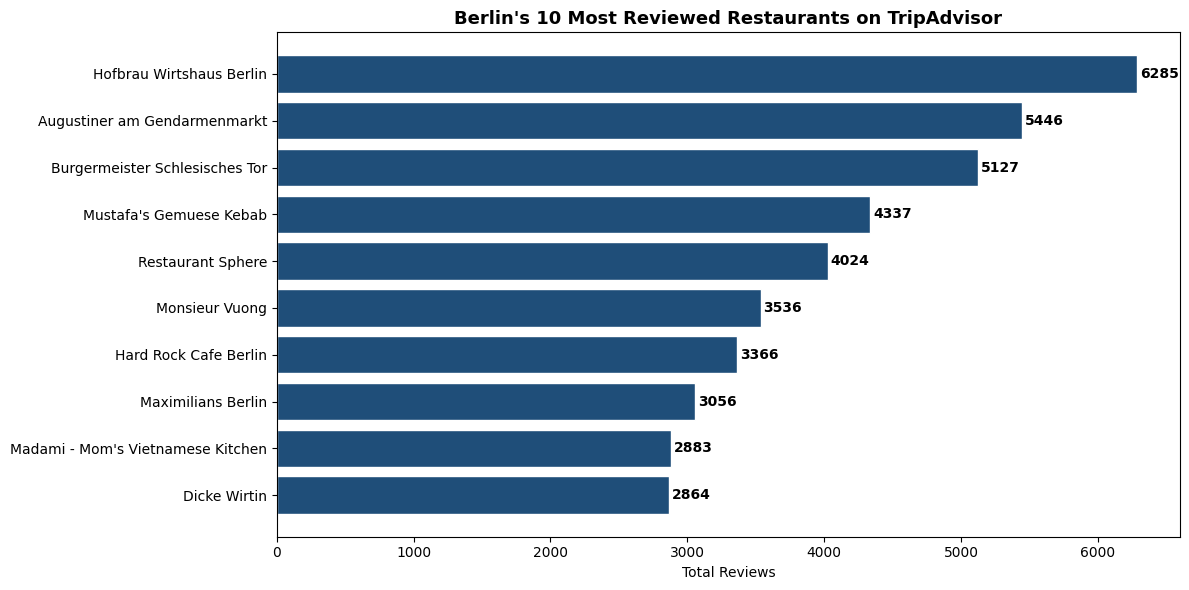

In [ ]:
# Top performing restaurants in berlin — let's find out
top_restaurants = berlin[berlin['total_reviews_count'] >= 100].copy()

top_rated = (top_restaurants
             .sort_values('avg_rating', ascending=False)
             .head(10)[['restaurant_name', 'cuisines',
                        'price_level', 'avg_rating',
                        'total_reviews_count', 'claimed']])

most_reviewed = (berlin
                 .sort_values('total_reviews_count', ascending=False)
                 .head(10)[['restaurant_name', 'cuisines',
                            'price_level', 'avg_rating',
                            'total_reviews_count', 'claimed']])

print("TOP 10 HIGHEST RATED (min 100 reviews)")
print("=" * 60)
print(top_rated.to_string(index=False))

print("\nTOP 10 MOST REVIEWED IN BERLIN")
print("=" * 60)
print(most_reviewed.to_string(index=False))

# final visual — top 10 most reviewed
fig, ax = plt.subplots(figsize=(12, 6))
most_reviewed_plot = most_reviewed.sort_values('total_reviews_count')
bars = ax.barh(most_reviewed_plot['restaurant_name'],
               most_reviewed_plot['total_reviews_count'],
               color='#1F4E79', edgecolor='white')
ax.set_title("Berlin's 10 Most Reviewed Restaurants on TripAdvisor",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Reviews')
for bar, val in zip(bars, most_reviewed_plot['total_reviews_count']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('top_restaurants.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Finding 6: What Berlin's Best Restaurants Have in Common

Every single restaurant in Berlin's top-rated list (minimum 100 reviews) is claimed. Not 8 out of 10. All 10. Combined with our A/B test result, this pattern is impossible to ignore.

The most reviewed list throws up a characteristically Berlin surprise, Mustafa's Gemuese Kebab, a street food stand charging budget prices, sits fourth in the entire city with 4,337 reviews and a 4.5 rating. Berlin rewards authenticity and value over prestige, consistently and emphatically.

Indian cuisine appears disproportionately among perfect-rated restaurants, pointing to an underserved but highly satisfied customer base well worth targeting for delivery platform expansion.

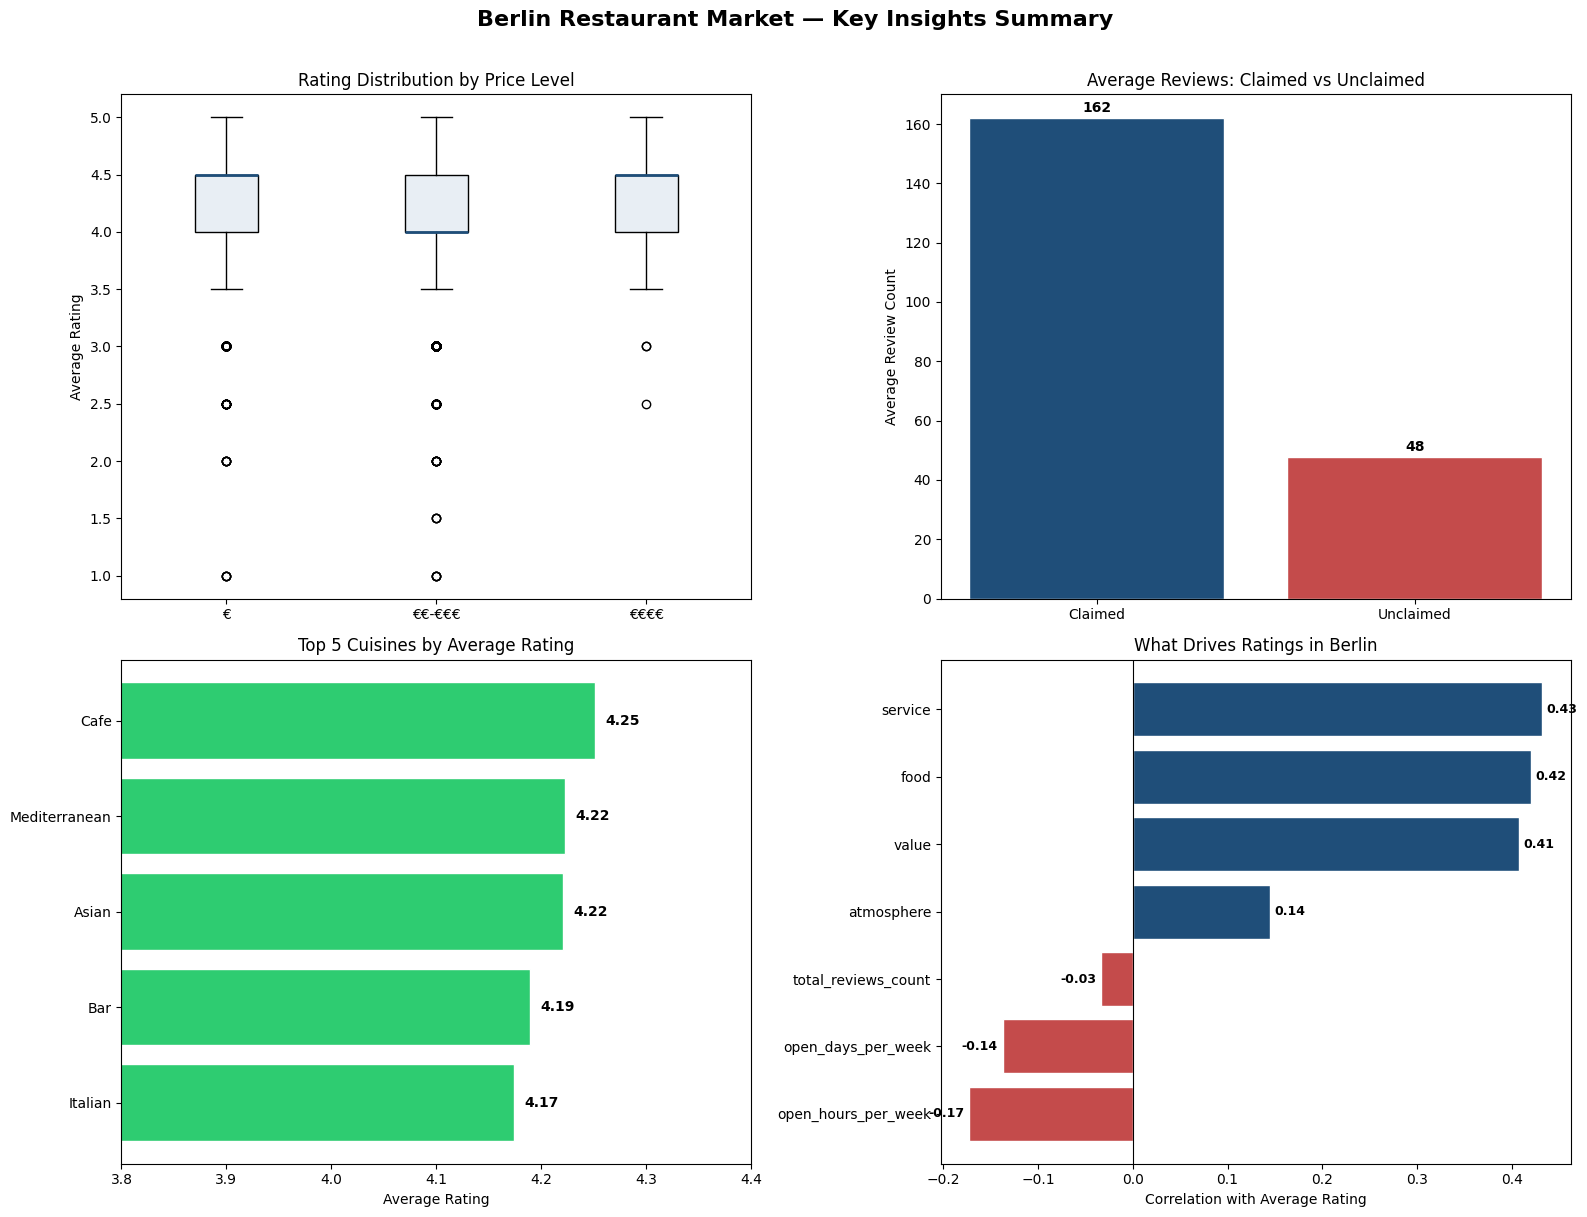

Summary dashboard saved!


In [ ]:
# SUMMARY VISUALISATION
# pulling together the five biggest findings into one clean chart

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Berlin Restaurant Market — Key Insights Summary',
             fontsize=16, fontweight='bold', y=1.01)

# 1. Rating distribution by price
price_order = ['€', '€€-€€€', '€€€€']
price_data = berlin[berlin['price_level'].isin(price_order)]
price_box_data = [price_data[price_data['price_level'] == p]['avg_rating'].values
                  for p in price_order]
axes[0,0].boxplot(price_box_data, tick_labels=price_order,
                  patch_artist=True,
                  boxprops=dict(facecolor='#E8EEF4'),
                  medianprops=dict(color='#1F4E79', linewidth=2))
axes[0,0].set_title('Rating Distribution by Price Level')
axes[0,0].set_ylabel('Average Rating')

# 2. Claimed vs unclaimed reviews
claimed_reviews = berlin.groupby('claimed')['total_reviews_count'].mean()
axes[0,1].bar(claimed_reviews.index, claimed_reviews.values,
              color=['#1F4E79', '#C44B4B'], edgecolor='white')
axes[0,1].set_title('Average Reviews: Claimed vs Unclaimed')
axes[0,1].set_ylabel('Average Review Count')
for i, v in enumerate(claimed_reviews.values):
    axes[0,1].text(i, v + 2, f'{v:.0f}', ha='center', fontweight='bold')

# 3. Top 5 cuisines by avg rating
top5_cuisine_rating = cuisine_rating_df.tail(5)
axes[1,0].barh(top5_cuisine_rating['cuisine'],
               top5_cuisine_rating['avg_rating'],
               color='#2ecc71', edgecolor='white')
axes[1,0].set_title('Top 5 Cuisines by Average Rating')
axes[1,0].set_xlabel('Average Rating')
axes[1,0].set_xlim(3.8, 4.4)
for i, v in enumerate(top5_cuisine_rating['avg_rating']):
    axes[1,0].text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')

# 4. What drives ratings — top correlations
driver_corr = corr_matrix['avg_rating'].drop('avg_rating').sort_values()
colors = ['#C44B4B' if v < 0 else '#1F4E79' for v in driver_corr.values]
axes[1,1].barh(driver_corr.index, driver_corr.values,
               color=colors, edgecolor='white')
axes[1,1].set_title('What Drives Ratings in Berlin')
axes[1,1].set_xlabel('Correlation with Average Rating')
axes[1,1].axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(driver_corr.values):
    axes[1,1].text(v + 0.005 if v >= 0 else v - 0.005, i,
                   f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right',
                   fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('berlin_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary dashboard saved!")